In [7]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit import cost
from scipy import stats
from sympy import * 
import pandas as pd
from helpers import *
r = np.random 
r.seed(42)

## 2.1

### 2.1.1

In [8]:
# Define variables:
x, y = symbols("x, y")
dx, dy = symbols("sigma_x, sigma_y")

# Define relation, and print:
z = cos(x**2)/ln(x*y)
lprint(latex(Eq(symbols('z'),z)))

# Calculate uncertainty and print:
dz = sqrt((z.diff(x) * dx)**2 + (z.diff(y) * dy)**2)
lprint(latex(Eq(symbols('sigma_z'), dz)))

# Turn expression into numerical functions 
fz = lambdify((x,y),z)
fdz = lambdify((x,dx,y,dy),dz)


# Define values and their errors
vx, vy = 1.71, 10.1
vdx, vdy = 0.05, 0.3

# Numerically evaluate expressions and print 
vz = fz(vx, vy)
vdz = fdz(vx, vdx, vy, vdy)
lprint(fr'z = {vz:.3f} \pm {vdz:.3f}\,')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Test of gaussian errors

-0.3626538196259753 -0.21964720088571327


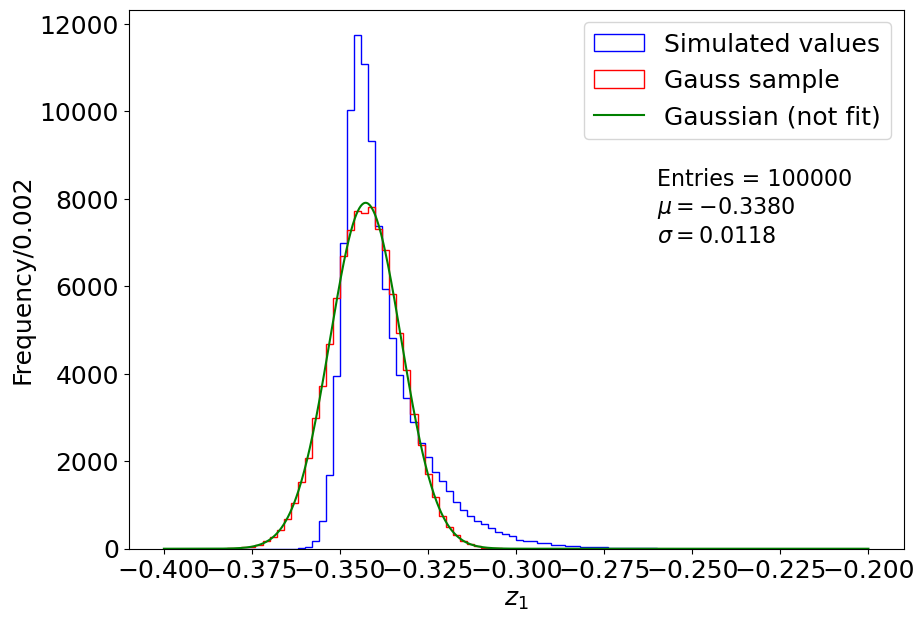

In [9]:
r = np.random
r.seed(42)
N_points = 100000

xs = stats.norm.rvs(loc=1.71, scale=0.05, size=N_points)
ys = stats.norm.rvs(loc=10.1, scale=0.3, size=N_points)
zs = np.cos(xs**2)/np.log(xs*ys)
print(np.min(zs), np.max(zs))
z1 = np.cos(1.71**2)/np.log(1.71*10.1)

xmin = -0.4
xmax = -0.2
Nbins = 100
binwidth = (xmax - xmin)/Nbins
samples = stats.norm.rvs(loc=z1, scale=vdz,size=len(zs))

xx = np.linspace(xmin, xmax, 1000)
fig, ax = plt.subplots(figsize=(10,7))
ax.hist(zs, bins=Nbins, range=(xmin, xmax), histtype='step', color='b', label='Simulated values');
ax.hist(samples, bins=Nbins, range=(xmin, xmax), histtype='step', color='r', label='Gauss sample');
ax.plot(xx, N_points*binwidth*stats.norm.pdf(xx, loc=z1, scale=vdz), '-g', label='Gaussian (not fit)');
ax.set_xlabel(r'$z_1$', fontsize=18)
ax.set_ylabel(f'Frequency/{binwidth:.3f}', fontsize=18)
ax.text(-0.26, 7000, fr'Entries = {N_points}' + '\n' + fr'$\mu={np.mean(zs):.4f}$' + '\n' + fr'$\sigma={np.std(zs):.4f}$', fontsize=16)
ax.legend(fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)

### 2.1.2

In [10]:
# Define variables:
x, y, rhoxy = symbols("x, y, rho_xy")
dx, dy = symbols("sigma_x, sigma_y")

# Define relation, and print:
z = cos(x**2)/ln(x*y)
lprint(latex(Eq(symbols('z'),z)))

# Calculate uncertainty and print:
dz = sqrt((z.diff(x) * dx)**2 + (z.diff(y) * dy)**2 + 2 * rhoxy * z.diff(x) * z.diff(y) * dx * dy)
lprint(latex(Eq(symbols('sigma_z'), dz)))

# Turn expression into numerical functions 
fz = lambdify((x,y),z)
fdz = lambdify((x,dx,y,dy,rhoxy),dz)


# Define values and their errors
rhoxy = 0.87
vx, vy = 1.71, 10.1
vdx, vdy = 0.05, 0.3

# Numerically evaluate expressions and print 
vz = fz(vx, vy)
vdz = fdz(vx, vdx, vy, vdy, rhoxy)
lprint(fr'z = {vz:.3f} \pm {vdz:.3f}\,')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## 2.2

### 2.2.1

In [11]:
dataframe = pd.read_csv('Data/data_WaterDensity.csv', header=0)
temp, density = dataframe.values.T
temp1, density1 = temp[:20], density[:20]
temp2, density2 = temp[20:40], density[20:40]
temp3, density3 = temp[40:60], density[40:60]
temp4, density4 = temp[60:80], density[60:80]
temp5, density5 = temp[80:], density[80:]
temps = np.array([np.mean(temp1), np.mean(temp2), np.mean(temp3), np.mean(temp4), np.mean(temp5)])

mean1, unc1 = compiler_esti(density1)
mean2, unc2 = compiler_esti(density2)
mean3, unc3 = compiler_esti(density3)
mean4, unc4 = compiler_esti(density4)
mean5, unc5 = compiler_esti(density5)
for i in range(5):
    print(f'For T= {temps[i]:.2f}: Mean = {eval(f"mean{i+1}"):.6f} ±  {eval(f"unc{i+1}"):.6f}')

For T= 0.20: Mean = 0.999855 ±  0.000003
For T= 2.30: Mean = 0.999952 ±  0.000003
For T= 3.90: Mean = 0.999972 ±  0.000003
For T= 5.90: Mean = 0.999951 ±  0.000004
For T= 7.80: Mean = 0.999865 ±  0.000004


### 2.2.2

In [12]:
def Chauvenet_filter(data): # returns a mask of accepted data points according to Chauvenet's criterion
    mean = np.mean(data)
    std = np.std(data)
    z = np.abs(data - mean)/std
    Pt = stats.norm.sf(z)*2
    PN = Pt*len(data)
    mask = PN >= 0.5
    return mask, z

def Chauvenet(data): # Applies the mask iteratively until no more points are rejected
    accepted = data.copy()
    rejected = np.array([])
    zvals = np.array([])
    while True:
        mask, z = Chauvenet_filter(accepted)
        if np.all(mask):
            break
        inv_mask = np.logical_not(mask)
        newly_rejected = accepted[inv_mask]
        z_rej = z[inv_mask]
        rejected = np.concatenate((rejected, newly_rejected))
        zvals = np.concatenate((zvals, z_rej))
        accepted = accepted[mask]
        
    return accepted, rejected, zvals

In [13]:
density1_acc, density1_rej, z1 = Chauvenet(density1)
density2_acc, density2_rej, z2 = Chauvenet(density2)
density3_acc, density3_rej, z3 = Chauvenet(density3)
density4_acc, density4_rej, z4 = Chauvenet(density4)
density5_acc, density5_rej, z5 = Chauvenet(density5)
for i in range(5):
    print(f'For T= {temps[i]:.2f}: Accepted points = {len(eval(f"density{i+1}_acc"))}, Rejected points = {len(eval(f"density{i+1}_rej"))}')
    print(f'Rejected points = {eval(f"density{i+1}_rej")} \nwith z-values = {eval(f"z{i+1}")}')
    print()

For T= 0.20: Accepted points = 14, Rejected points = 6
Rejected points = [0.9998939 0.9998328 0.999832  0.9998672 0.9998468 0.9998508] 
with z-values = [3.27070846 2.5365456  2.63622371 2.964003   2.248554   2.58277288]

For T= 2.30: Accepted points = 17, Rejected points = 3
Rejected points = [0.9999116 0.999996  0.9999576] 
with z-values = [3.00819561 3.22610051 2.31864913]

For T= 3.90: Accepted points = 18, Rejected points = 2
Rejected points = [0.9999182 0.9999697] 
with z-values = [4.30879332 2.67668085]

For T= 5.90: Accepted points = 16, Rejected points = 4
Rejected points = [1.0000143 0.9999809 0.9999651 0.9999263] 
with z-values = [3.6016827  3.25656979 2.84662169 2.98181744]

For T= 7.80: Accepted points = 16, Rejected points = 4
Rejected points = [0.9998054 0.9999117 0.9998969 0.9998681] 
with z-values = [3.22095494 2.53007403 4.01198979 2.32300375]



In [14]:
mean1_acc, unc1_acc = compiler_esti(density1_acc)
mean2_acc, unc2_acc = compiler_esti(density2_acc)
mean3_acc, unc3_acc = compiler_esti(density3_acc)
mean4_acc, unc4_acc = compiler_esti(density4_acc)
mean5_acc, unc5_acc = compiler_esti(density5_acc)
print(f'After Chauvenet filtering:')
for i in range(5):
    print(f'For T= {temps[i]:.2f}: Mean = {eval(f"mean{i+1}_acc"):.7f} ±  {eval(f"unc{i+1}_acc"):.7f}')

After Chauvenet filtering:
For T= 0.20: Mean = 0.9998557 ±  0.0000004
For T= 2.30: Mean = 0.9999518 ±  0.0000005
For T= 3.90: Mean = 0.9999752 ±  0.0000004
For T= 5.90: Mean = 0.9999462 ±  0.0000004
For T= 7.80: Mean = 0.9998635 ±  0.0000004


### 2.2.3

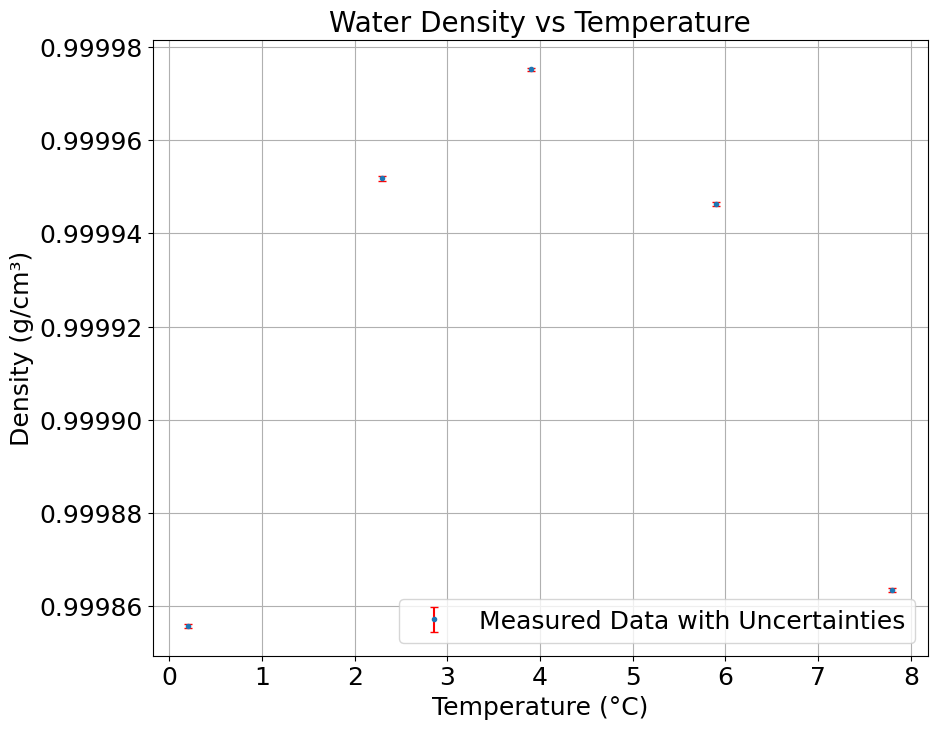

In [15]:
means = np.array([mean1_acc, mean2_acc, mean3_acc, mean4_acc, mean5_acc])
uncs = np.array([unc1_acc, unc2_acc, unc3_acc, unc4_acc, unc5_acc])
fig, ax = plt.subplots(figsize=(10,8))

ax.errorbar(temps, means, yerr=uncs, fmt='.', capsize=3, ecolor='red', label='Measured Data with Uncertainties')
ax.set_xlabel('Temperature (°C)', fontsize=18)
ax.set_ylabel('Density (g/cm³)', fontsize=18)
ax.set_title('Water Density vs Temperature', fontsize=20)
ax.legend(fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.grid();

In [16]:
z_23 = np.abs((mean2_acc - mean3_acc))/np.sqrt(unc2_acc**2 + unc3_acc**2)
z_34 = np.abs((mean3_acc - mean4_acc))/np.sqrt(unc3_acc**2 + unc4_acc**2)
print(f'z_23 = {z_23:.2f}')
print(f'z_34 = {z_34:.2f}')
p_23 = stats.norm.sf(z_23)*2
p_34 = stats.norm.sf(z_34)*2
print(f'p_23 = {p_23:.20f}')
print(f'p_34 = {p_34:.20f}')

z_23 = 37.39
z_34 = 50.75
p_23 = 0.00000000000000000000
p_34 = 0.00000000000000000000


### 2.2.4

In [17]:
def poly2(x, a, b, c):
    return a*x**2 + b*x + c

def gauss(x, N, mu, sigma, c):
    return N*stats.norm.pdf(x, mu, sigma) + c

In [18]:
cfit_pol = cost.LeastSquares(temps, means, uncs, poly2)
mfit_pol = Minuit(cfit_pol, a= -0.0002, b= 0.02, c= 1)
mfit_pol.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 27.16 (χ²/ndof = 13.6)     │              Nfcn = 64               │
│ EDM = 1.5e-08 (Goal: 0.0002)     │            time = 0.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │ -8.001e-6 │ 0.029e-6  │            │            │         │         │       │
│ 1 │ b    │ 64.89e-6  │  0.24e-6  │            │            │         │         │       │
│ 2 │ c    │999.8435e-3│ 0.0004e-3 │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────────────────┐
│   │         a         b         c │
├───┼───────────────────────────────┤
│ a │  8.25e-16  -6.5e-15   6.6e-15 │
│ b │  -6.5e-15  5.55e-14 -0.07e-12 │
│ c │   6.6e-15 -0.07e-12  1.55e-13 │
└───┴───────────────────────────────┘

In [19]:
cfit_gauss = cost.LeastSquares(temps, means, uncs, gauss)
mfit_gauss = Minuit(cfit_gauss, N=0.5, mu=4, sigma=1, c=1)
mfit_gauss.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 34.97 (χ²/ndof = 35.0)     │              Nfcn = 890              │
│ EDM = 0.148 (Goal: 0.0002)       │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           ABOVE call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │        Covariance APPROXIMATE        │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N     │  11.5e-3  │  0.6e-3   │            │            │         │         │       │
│ 1 │ mu    │   4.061   │   0.005   │            │            │         │         │       │
│ 2 │ sigma │   6.39    │   0.11    │            │            │         │         │       │
│ 3 │ c     │999.258e-3 │ 0.023e-3  │            │            │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬─────────────────────────────────────────────┐
│       │          N         mu      sigma          c │
├───────┼─────────────────────────────────────────────┤
│     N │   3.13e-07    0.02e-6   62.51e-6   -12.7e-9 │
│    mu │    0.02e-6   2.04e-05   0.004e-3    -0.4e-9 │
│ sigma │   62.51e-6   0.004e-3     0.0125 -2.5271e-6 │
│     c │   -12.7e-9    -0.4e-9 -2.5271e-6   5.14e-10 │
└───────┴─────────────────────────────────────────────┘

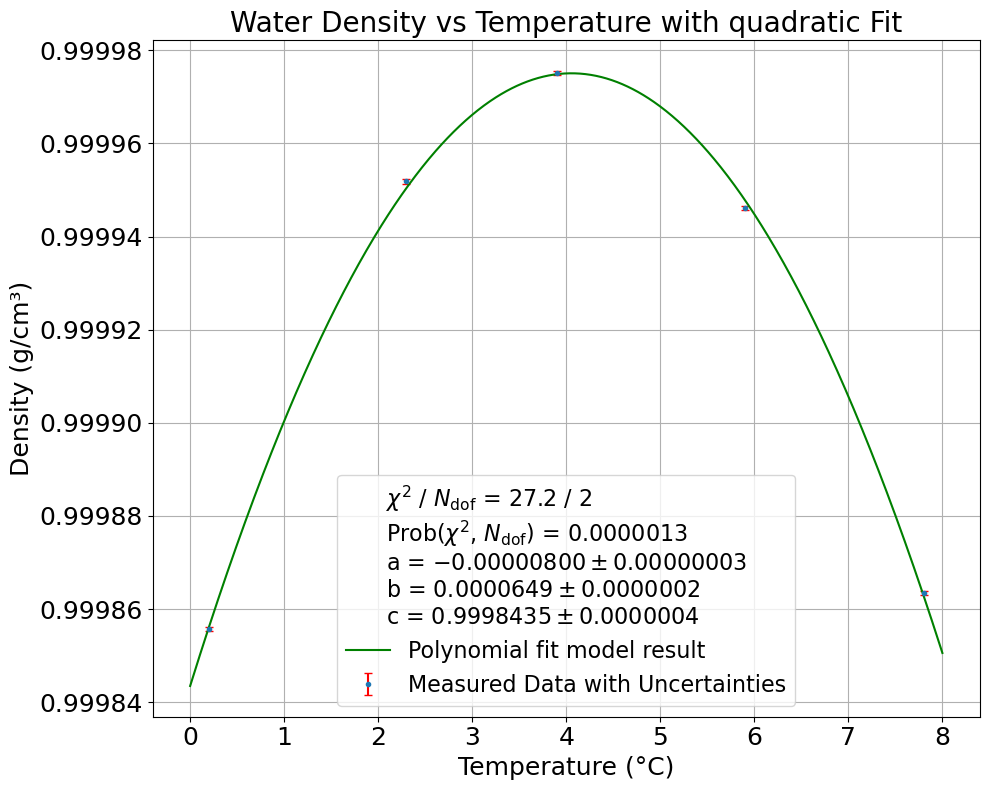

In [20]:
fig, ax = plt.subplots(figsize=(10,8))

ax.errorbar(temps, means, yerr=uncs, fmt='.', capsize=3, ecolor='red', label='Measured Data with Uncertainties')
ax.set_xlabel('Temperature (°C)', fontsize=18)
ax.set_ylabel('Density (g/cm³)', fontsize=18)
ax.set_title('Water Density vs Temperature with quadratic Fit', fontsize=20)
ax.legend(fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.grid();

# Adding fit function to plot:
x_axis = np.linspace(0, 8, 1000)
ax.plot(x_axis, poly2(x_axis, *mfit_pol.values[:]), '-g', label= r"Polynomial fit model result") 

# Adding fit results to plot:
chi2 = mfit_pol.fval                     # ChiSquare value
Ndof = len(temps) - mfit_pol.nfit     # Number of (non-empty) bins
Prob = stats.chi2.sf(chi2, Ndof)     # ChiSquare probability given Ndof

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.7f}",]
for p, v, e in zip(mfit_pol.parameters, mfit_pol.values[:], mfit_pol.errors[:]) :
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))                                # Number of significant digits
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');
fig.tight_layout()

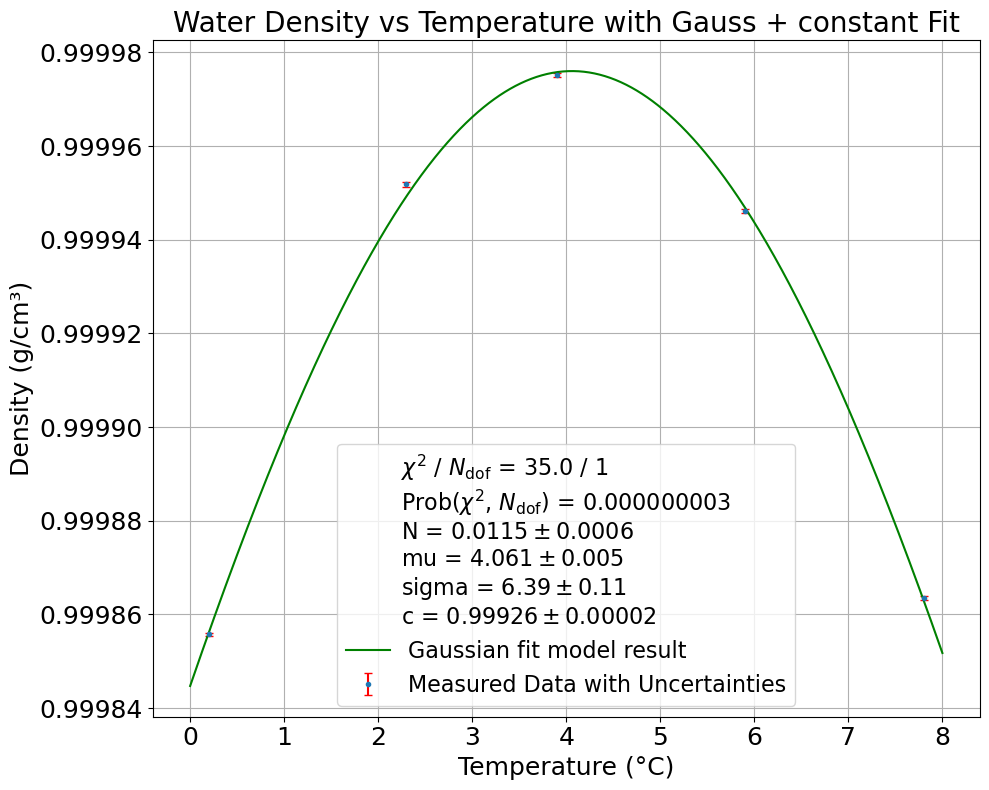

In [21]:
fig, ax = plt.subplots(figsize=(10,8))

ax.errorbar(temps, means, yerr=uncs, fmt='.', capsize=3, ecolor='red', label='Measured Data with Uncertainties')
ax.set_xlabel('Temperature (°C)', fontsize=18)
ax.set_ylabel('Density (g/cm³)', fontsize=18)
ax.set_title('Water Density vs Temperature with Gauss + constant Fit', fontsize=20)
ax.legend(fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.grid();

# Adding fit function to plot:
x_axis = np.linspace(0, 8, 1000)
ax.plot(x_axis, gauss(x_axis, *mfit_gauss.values[:]), '-g', label= r"Gaussian fit model result") 

# Adding fit results to plot:
chi2 = mfit_gauss.fval                     # ChiSquare value
Ndof = len(temps) - mfit_gauss.nfit     # Number of (non-empty) bins
Prob = stats.chi2.sf(chi2, Ndof)     # ChiSquare probability given Ndof

fit_info = [f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {Ndof}", f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {Prob:.9f}",]
for p, v, e in zip(mfit_gauss.parameters, mfit_gauss.values[:], mfit_gauss.errors[:]) :
    Ndecimals = max(0,-np.int32(np.log10(e)-1-np.log10(2)))                                # Number of significant digits
    fit_info.append(f"{p} = ${v:{10}.{Ndecimals}{"f"}} \\pm {e:{10}.{Ndecimals}{"f"}}$")

plt.legend(title="\n".join(fit_info), fontsize=16, title_fontsize = 16, alignment = 'center');
fig.tight_layout()

In [22]:
a, b, c = mfit_pol.values[:]
da, db, dc = mfit_pol.errors[:]
T_max = -b/(2*a)
eT_max = np.sqrt( (db/(2*a))**2 + (b*da/(2*a**2))**2 )
print('From Polynomial fit:')
print(f"T_max = {T_max:.2f} ± {eT_max:.2f}")
mu = mfit_gauss.values[1]
e_mu = mfit_gauss.errors[1]
print('From Gaussian fit:')
print(f"T_max = {mu:.3f} ± {e_mu:.3f}")

z_fit = np.abs((T_max - mu))/np.sqrt(eT_max**2 + e_mu**2)
print(f'z_fit = {z_fit:.4f}')
print(f'p_fit = {stats.norm.sf(z_fit)*2:.2f}')

From Polynomial fit:
T_max = 4.06 ± 0.02
From Gaussian fit:
T_max = 4.061 ± 0.005
z_fit = 0.2602
p_fit = 0.79


## 2.3

### 2.3.1

In [23]:
# Define variables:
beta  = symbols("beta")
d_beta = symbols("sigma_beta")

# Define relation, and print:
gamma = 1 / sqrt(1 - beta**2)
lprint(latex(Eq(symbols('gamma'),gamma)))

# Calculate uncertainty and print:
dgamma = sqrt((gamma.diff(beta) * d_beta)**2)
lprint(latex(Eq(symbols('sigma_gamma'), dgamma)))
# Turn expression into numerical functions 
fgamma = lambdify((beta,),gamma)
fdgamma = lambdify((beta,d_beta),dgamma)


# Define values and their errors
vbeta = 0.50
vd_beta = 0.02

# Numerically evaluate expressions and print 
vgamma = fgamma(vbeta)
vdgamma = fdgamma(vbeta, vd_beta)
lprint(fr'γ = {vgamma:.4f} \pm {vdgamma:.4f}\,')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### 2.3.2

In [24]:
# Define values and their errors
vbeta = 0.95
vd_beta = 0.02

# Numerically evaluate expressions and print 
vgamma = fgamma(vbeta)
vdgamma = fdgamma(vbeta, vd_beta)
lprint(fr'γ = {vgamma:.4f} \pm {vdgamma:.4f}\,')
vgamma_up = fgamma(vbeta + vd_beta)
vgamma_low = fgamma(vbeta - vd_beta)
lprint(fr'γ_u = {vgamma_up:.4f}\,')
lprint(fr'γ_l = {vgamma_low:.4f}\,')
diff_up = vgamma_up - vgamma
diff_low = vgamma - vgamma_low
lprint(fr'σ_+ = {diff_up:.4f}\,')
lprint(fr'σ_- = {diff_low:.4f}\,')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

1.9641237477767828 308.23784756298664


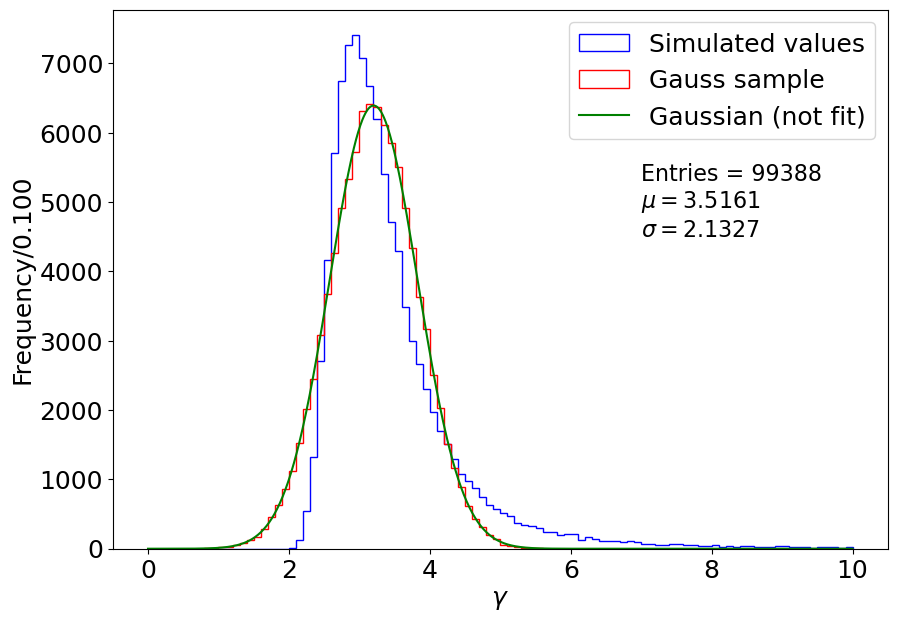

In [25]:
r = np.random
r.seed(42)
N_points = 100000

betas = stats.norm.rvs(loc=0.95, scale=0.02, size=N_points)
betas = betas[betas<1]
gammas = 1 / np.sqrt(1 - betas**2)
print(np.min(gammas), np.max(gammas))
gamma1 = 1 / np.sqrt(1 - 0.95**2)

xmin = 0
xmax = 10
Nbins = 100
binwidth = (xmax - xmin)/Nbins
samples = stats.norm.rvs(loc=gamma1, scale=vdgamma,size=len(gammas))

xx = np.linspace(xmin, xmax, 1000)
fig, ax = plt.subplots(figsize=(10,7))
ax.hist(gammas, bins=Nbins, range=(xmin, xmax), histtype='step', color='b', label='Simulated values');
ax.hist(samples, bins=Nbins, range=(xmin, xmax), histtype='step', color='r', label='Gauss sample');
ax.plot(xx, N_points*binwidth*stats.norm.pdf(xx, loc=gamma1, scale=vdgamma), '-g', label='Gaussian (not fit)');
ax.set_xlabel(r'$\gamma$', fontsize=18)
ax.set_ylabel(f'Frequency/{binwidth:.3f}', fontsize=18)
ax.text(7, 4500, fr'Entries = {len(betas)}' + '\n' + fr'$\mu={np.mean(gammas):.4f}$' + '\n' + fr'$\sigma={np.std(gammas):.4f}$', fontsize=16)
ax.legend(fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)

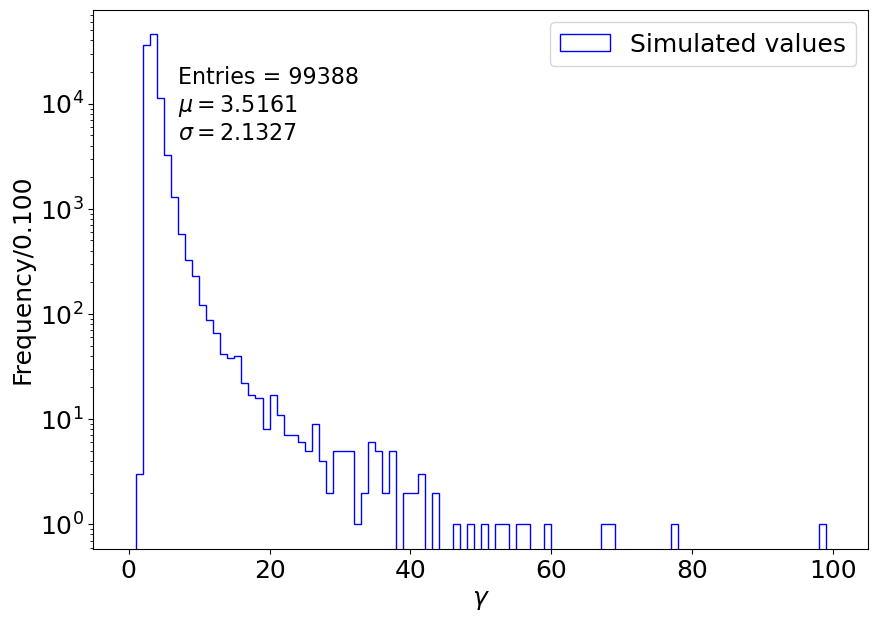

In [26]:
fig, ax = plt.subplots(figsize=(10,7))
ax.hist(gammas, bins=Nbins, range=(xmin, 100), histtype='step', color='b', label='Simulated values');
ax.set_xlabel(r'$\gamma$', fontsize=18)
ax.set_ylabel(f'Frequency/{binwidth:.3f}', fontsize=18)
ax.text(7, 4500, fr'Entries = {len(betas)}' + '\n' + fr'$\mu={np.mean(gammas):.4f}$' + '\n' + fr'$\sigma={np.std(gammas):.4f}$', fontsize=16)
ax.legend(fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_yscale('log')